# 01 - Inspección orientada a balanceo temporal (v2 — Ventanas Clínicas)

Este notebook realiza un EDA por subgrupos orientado a decisiones experimentales de balanceo para predicción de glucosa en pacientes con DM1.

**Versión 2:** sustituye parámetros arbitrarios por ventanas de observación clínicamente validadas (1 día, 14 días, 90 días), maximiza los pacientes incluidos por ventana y hace visibles los gaps de continuidad de datos.


## Glosario operativo y de auditoría (EDA temporal v2)

Este glosario fija el significado exacto de la terminología usada en este notebook para que la lectura sea reproducible y auditable.

- **Episodio**: tramo consecutivo de mediciones de un mismo paciente con la misma clase clínica (`hypoglycemia`, `normoglycemia`, `hyperglycemia`).
- **Inicio de episodio**: primera fila donde cambia la clase respecto a la medición anterior del mismo paciente (`class_label != prev_class`).
- **Paso**: una observación temporal individual dentro de la serie de un paciente.
- **Paso relativo (`rel_step`)**: posición respecto al inicio del episodio. `0` es el cruce/arranque del episodio; negativos son contexto previo; positivos son evolución posterior.
- **Ventana clínica de observación**: período estándar en vigilancia continua de pacientes DM1: **1 día** (detección aguda), **14 días** (subagudo / post-alta), **90 días** (seguimiento crónico).
- **Sub-serie continua**: fragmento de la serie temporal de un paciente sin valores nulos, con duración ≥ la ventana clínica de interés.
- **Paciente elegible por ventana**: paciente que dispone de al menos una sub-serie continua de la duración requerida.
- **Varianza previa (`pre_var`)**: dispersión de glucosa dentro de la ventana previa al evento.
- **Pendiente previa (`pre_slope`)**: tendencia lineal en la ventana previa; negativa indica caída, positiva subida.
- **Ratio de desbalanceo**: cociente entre clase mayoritaria y minoritaria por paciente.
- **Separabilidad**: grado en que las clases se distinguen por sus estadísticos temporales (estimada con tamaño de efecto de Cohen d).


In [2]:
import warnings
warnings.filterwarnings('ignore')

import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

from IPython.display import display, Markdown

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

# ─── Ventanas clínicas (ver justificación en celda siguiente) ───
CLINICAL_WINDOWS = {
    '1d':  1,    # días
    '14d': 14,
    '90d': 90,
}

def find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'T1DiabetesGranada').exists():
            return candidate
    raise FileNotFoundError('No se encontró la carpeta data/T1DiabetesGranada desde el directorio actual.')

ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / 'data' / 'T1DiabetesGranada'

print(f'ROOT detectado: {ROOT}')
print(f'DATA_DIR: {DATA_DIR}')


ROOT detectado: c:\Users\User\Desktop\TFM-Glucose-Prediction
DATA_DIR: c:\Users\User\Desktop\TFM-Glucose-Prediction\data\T1DiabetesGranada


## Justificación clínica de las ventanas de observación

### Por qué 1 día, 14 días y 90 días — y no valores arbitrarios

En el seguimiento clínico de pacientes con DM1, la comunidad endocrinológica (ADA Standards of Medical Care, 2024; Diabetes Technology & Therapeutics) ha consolidado tres horizontes de observación que responden a fisiología y práctica asistencial:

| Ventana | Justificación clínica | Uso en CGM / endocrinología |
|---|---|---|
| **1 día (24 h)** | Ciclo circadiano de glucosa. Los picos postprandiales y los valles nocturnos tienen periodicidad de ~24 h. El riesgo de hipoglucemia nocturna se evalúa sobre series de 24 h completas. | Revisión de perfil glucémico diario (AGP daily profile). |
| **14 días** | Periodo mínimo recomendado para estimar el *Time in Range* (TIR) con precisión estadística (±5%; Danne et al., 2019, Diabetes Care). El alta hospitalaria y el ajuste de insulinoterapia basal se programan habitualmente a las 2 semanas. | Informe estándar AGP de 14 días. Base del reporte Libre/Dexcom para consulta. |
| **90 días** | Ventana de hemoglobina glicosilada (HbA1c). Refleja la memoria glucémica de los 3 meses anteriores y es el indicador de control crónico por excelencia. Los ajustes de tratamiento de largo plazo se evalúan en este horizonte. | Revisión trimestral clínica. Periodo estándar de estudios de intervención DM1. |

### Por qué NO parámetros numéricos arbitrarios

El notebook anterior usaba `pre_steps=24`, `post_steps=12` y `max_per_class=1000` sin justificación clínica ni estadística. Esos números son **incómodos epistemológicamente**: implican que el modelo aprende sobre una "memoria" de 24 pasos cuya duración real en minutos varía entre pacientes según la frecuencia de medición. Sustituirlos por días reales:

1. Garantiza comparabilidad entre pacientes con diferente frecuencia de muestreo.
2. Ancla la decisión en evidencia clínica publicada.
3. Facilita la interpretación de resultados a clínicos no técnicos.

### Sobre el muestreo anterior de 1 000 eventos por clase

El submuestreo a 1 000 era una decisión de coste computacional no justificada. En este notebook se **maximizan los pacientes elegibles** por ventana: se incluye a todos los pacientes que dispongan de al menos una sub-serie continua de la duración requerida. Solo si el volumen supera un umbral de memoria RAM se aplica submuestreo explícitamente documentado.


In [3]:
# ─── Carga y normalización de datos ───────────────────────────────────────────
patient_info = pd.read_csv(DATA_DIR / 'Patient_info.csv')
glucose = pd.read_parquet(DATA_DIR / 'Glucose_measurements_T1DiabetesGranada_FILTERED_2026-03-27.parquet')

# Normalización de columnas
if 'Patient_Id' in patient_info.columns and 'Patient_ID' not in patient_info.columns:
    patient_info.rename(columns={'Patient_Id': 'Patient_ID'}, inplace=True)

rename_map = {
    'patient_id': 'Patient_ID',
    'measurement_date': 'Measurement_date',
    'measurement_time': 'Measurement_time',
    'measurement': 'Measurement'
}
glucose.rename(columns={k: v for k, v in rename_map.items() if k in glucose.columns}, inplace=True)
if 'Patient_Id' in glucose.columns and 'Patient_ID' not in glucose.columns:
    glucose.rename(columns={'Patient_Id': 'Patient_ID'}, inplace=True)

patient_info['Patient_ID'] = patient_info['Patient_ID'].astype(str)
glucose['Patient_ID'] = glucose['Patient_ID'].astype(str)

# Parseo temporal
if {'Measurement_date', 'Measurement_time'}.issubset(glucose.columns):
    glucose['timestamp'] = pd.to_datetime(
        glucose['Measurement_date'].astype(str) + ' ' + glucose['Measurement_time'].astype(str),
        errors='coerce'
    )
elif 'Measurement_date' in glucose.columns:
    glucose['timestamp'] = pd.to_datetime(glucose['Measurement_date'], errors='coerce')
elif '15min' in glucose.columns:
    glucose['timestamp'] = pd.to_datetime(glucose['15min'], errors='coerce')
elif '5min' in glucose.columns:
    glucose['timestamp'] = pd.to_datetime(glucose['5min'], errors='coerce')
else:
    raise ValueError('No se encontraron columnas de fecha/hora en Glucose_measurements.parquet')

glucose['Measurement'] = pd.to_numeric(glucose['Measurement'], errors='coerce').astype(float)

def glucose_class(value: float) -> str:
    if pd.isna(value):
        return 'missing'
    if value < 70:
        return 'hypoglycemia'
    if value <= 180:
        return 'normoglycemia'
    return 'hyperglycemia'

glucose['class_label'] = glucose['Measurement'].apply(glucose_class)
glucose = glucose.sort_values(['Patient_ID', 'timestamp']).reset_index(drop=True)

print('Shapes cargados:')
print('patient_info:', patient_info.shape)
print('glucose:     ', glucose.shape)
print('Rango temporal:', glucose['timestamp'].min(), '→', glucose['timestamp'].max())
print(f'Pacientes únicos en glucose: {glucose["Patient_ID"].nunique()}')


Shapes cargados:
patient_info: (736, 11)
glucose:      (30477434, 8)
Rango temporal: 2018-01-06 13:39:00 → 2022-03-21 21:00:00
Pacientes únicos en glucose: 643


In [4]:
def summarize_schema(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        dtype = str(s.dtype)
        nulls = int(s.isna().sum())
        null_pct = float(s.isna().mean() * 100)
        min_val, max_val = None, None
        if pd.api.types.is_numeric_dtype(s):
            min_val = s.min(skipna=True)
            max_val = s.max(skipna=True)
        elif pd.api.types.is_datetime64_any_dtype(s):
            min_val = s.min(skipna=True)
            max_val = s.max(skipna=True)
        else:
            non_null = s.dropna().astype(str)
            if len(non_null) > 0:
                min_val = non_null.min()
                max_val = non_null.max()
        rows.append({
            'dataset': name, 'column': col, 'dtype': dtype,
            'nulls': nulls, 'null_pct': round(null_pct, 2),
            'min': min_val, 'max': max_val, 'n_unique': int(s.nunique(dropna=True))
        })
    return pd.DataFrame(rows)

schema_report = pd.concat([
    summarize_schema(patient_info, 'patient_info'),
    summarize_schema(glucose, 'glucose_measurements')
], ignore_index=True)

display(Markdown('### Schema completo por archivo'))
display(schema_report)

display(Markdown('### Definición de clases clínicas'))
print('hypoglycemia : glucosa < 70 mg/dL')
print('normoglycemia: 70–180 mg/dL')
print('hyperglycemia: > 180 mg/dL')


### Schema completo por archivo

,dataset,column,dtype,nulls,null_pct,min,max,n_unique
0,patient_info,Patient_ID,object,0,0.00,LIB193263,LIB194166,736
1,patient_info,Sex,object,0,0.00,F,M,2
2,patient_info,Birth_year,int64,0,0.00,1936,2005,69
3,patient_info,Initial_measurement_date,object,0,0.00,2018-01-06,2022-02-24,329
4,patient_info,Final_measurement_date,object,0,0.00,2019-01-20,2022-03-21,173
5,patient_info,Number_of_days_with_measures,int64,0,0.00,8,1463,468
6,patient_info,Number_of_measurements,int64,0,0.00,400,137292,729
7,patient_info,Initial_biochemical_parameters_date,object,13,1.77,2018-01-01,2021-08-23,271
8,patient_info,Final_biochemical_parameters_date,object,13,1.77,2018-11-21,2022-03-21,238
9,patient_info,Number_of_biochemical_parameters,float64,13,1.77,4.0,846.0,234


### Definición de clases clínicas

hypoglycemia : glucosa < 70 mg/dL
normoglycemia: 70–180 mg/dL
hyperglycemia: > 180 mg/dL


## Bloque 0 — Análisis de continuidad de datos y construcción de sub-series

### Por qué es necesario este bloque

Las series glucémicas de CGM presentan **gaps de valores nulos** por múltiples causas clínicas y tecnológicas: pérdida de señal del sensor, retirada voluntaria del dispositivo, periodos de hospitalización sin monitorización, o simplemente que el paciente no llevaba el sensor puesto. Ignorar estos gaps genera dos problemas graves:

1. **Sesgo en las visualizaciones de episodios**: si se usan ventanas que cruzan un gap nulo, la media alineada al evento mezcla fragmentos reales con interpolaciones implícitas o ceros, distorsionando la trayectoria observada.
2. **Sobreestimación de cobertura temporal**: el paciente parece tener 90 días de datos cuando en realidad solo tiene fragmentos dispersos.

### Decisión metodológica: sub-series continuas por ventana clínica

Para cada paciente y cada ventana clínica (1d, 14d, 90d), se identifican los **fragmentos continuos** de la serie sin nulos que tienen una duración ≥ la ventana requerida. Solo esos fragmentos se usan en los análisis de episodios de ese paciente y esa ventana.

**Criterio de continuidad**: se considera que hay un gap si entre dos mediciones consecutivas del mismo paciente el salto temporal supera 1.5 veces el intervalo mediano del paciente (adaptativo, robusto a distintas frecuencias de muestreo).

**Pacientes elegibles**: se incluyen **todos** los pacientes que tengan al menos una sub-serie continua válida para la ventana de interés. No se aplica ningún techo arbitrario de pacientes.


In [5]:
# ─── Construcción de sub-series continuas por paciente ────────────────────────
#
# Hipótesis clínica: los gaps en la monitorización CGM no son aleatorios; pueden
# coincidir con periodos de hiperglucemia severa o ingreso hospitalario, lo que
# introduce sesgo de selección si se ignoran. Hacerlos explícitos es una decisión
# de integridad analítica, no solo de limpieza de datos.

class_order = ['hypoglycemia', 'normoglycemia', 'hyperglycemia']

# Solo filas con medición válida y clase clínica
glucose_valid = glucose[glucose['class_label'].isin(class_order)].copy()
glucose_valid = glucose_valid.dropna(subset=['timestamp', 'Measurement'])
glucose_valid = glucose_valid.sort_values(['Patient_ID', 'timestamp']).reset_index(drop=True)

def build_continuous_subseries(df: pd.DataFrame, window_days: int, gap_multiplier: float = 1.5) -> pd.DataFrame:
    """
    Para cada paciente identifica sub-series continuas de duración >= window_days.
    Retorna DataFrame con columnas: Patient_ID, segment_id, start_ts, end_ts, n_obs, duration_days.
    Un gap se define como un salto temporal > gap_multiplier * mediana del intervalo del paciente.
    """
    records = []
    min_duration = pd.Timedelta(days=window_days)

    for pid, grp in df.groupby('Patient_ID', sort=False):
        grp = grp.sort_values('timestamp').reset_index(drop=True)
        diffs = grp['timestamp'].diff()

        # Mediana del intervalo de muestreo del paciente (robusto)
        median_interval = diffs.dropna().median()
        if pd.isna(median_interval) or median_interval.total_seconds() == 0:
            continue
        gap_threshold = gap_multiplier * median_interval

        # Identificar inicio de cada segmento
        is_gap = (diffs > gap_threshold).fillna(True)  # primera fila siempre inicia segmento
        seg_ids = is_gap.cumsum()

        for sid, seg in grp.groupby(seg_ids):
            if len(seg) < 2:
                continue
            duration = seg['timestamp'].iloc[-1] - seg['timestamp'].iloc[0]
            if duration >= min_duration:
                records.append({
                    'Patient_ID': pid,
                    'segment_id': f'{pid}_seg{sid}',
                    'start_ts': seg['timestamp'].iloc[0],
                    'end_ts': seg['timestamp'].iloc[-1],
                    'n_obs': len(seg),
                    'duration_days': duration.total_seconds() / 86400
                })
    return pd.DataFrame(records)

# Construir sub-series para cada ventana clínica
subseries_by_window = {}
eligibility_summary = []

for wname, wdays in CLINICAL_WINDOWS.items():
    ss = build_continuous_subseries(glucose_valid, window_days=wdays)
    subseries_by_window[wname] = ss
    n_patients = ss['Patient_ID'].nunique() if not ss.empty else 0
    n_segments = len(ss)
    avg_duration = ss['duration_days'].mean() if not ss.empty else 0
    eligibility_summary.append({
        'ventana': wname,
        'días_requeridos': wdays,
        'n_pacientes_elegibles': n_patients,
        'n_sub_series': n_segments,
        'cobertura_media_días': round(avg_duration, 1)
    })
    print(f'Ventana {wname}: {n_patients} pacientes elegibles, {n_segments} sub-series válidas')

eligibility_df = pd.DataFrame(eligibility_summary)
display(Markdown('### Tabla resumen de elegibilidad por ventana clínica'))
display(eligibility_df)


Ventana 1d: 643 pacientes elegibles, 50762 sub-series válidas
Ventana 14d: 7 pacientes elegibles, 13 sub-series válidas
Ventana 90d: 1 pacientes elegibles, 1 sub-series válidas


### Tabla resumen de elegibilidad por ventana clínica

,ventana,días_requeridos,n_pacientes_elegibles,n_sub_series,cobertura_media_días
0,1d,1,643,50762,3.3
1,14d,14,7,13,35.5
2,90d,90,1,1,93.0


### Visualización de continuidad de datos

**Decisión de diseño**: mostramos explícitamente los gaps como espacios en blanco en el eje temporal, no los interpolamos ni los omitimos silenciosamente. Un clínico que revise este notebook debe ver exactamente cuánta cobertura real hay por paciente y dónde están las discontinuidades.

**Elección de pacientes a visualizar**: se seleccionan los `N` pacientes con mayor número de sub-series válidas para la ventana de 14 días (la más relevante para uso clínico rutinario), lo que maximiza la información mostrada sin introducir sesgo de selección manual.


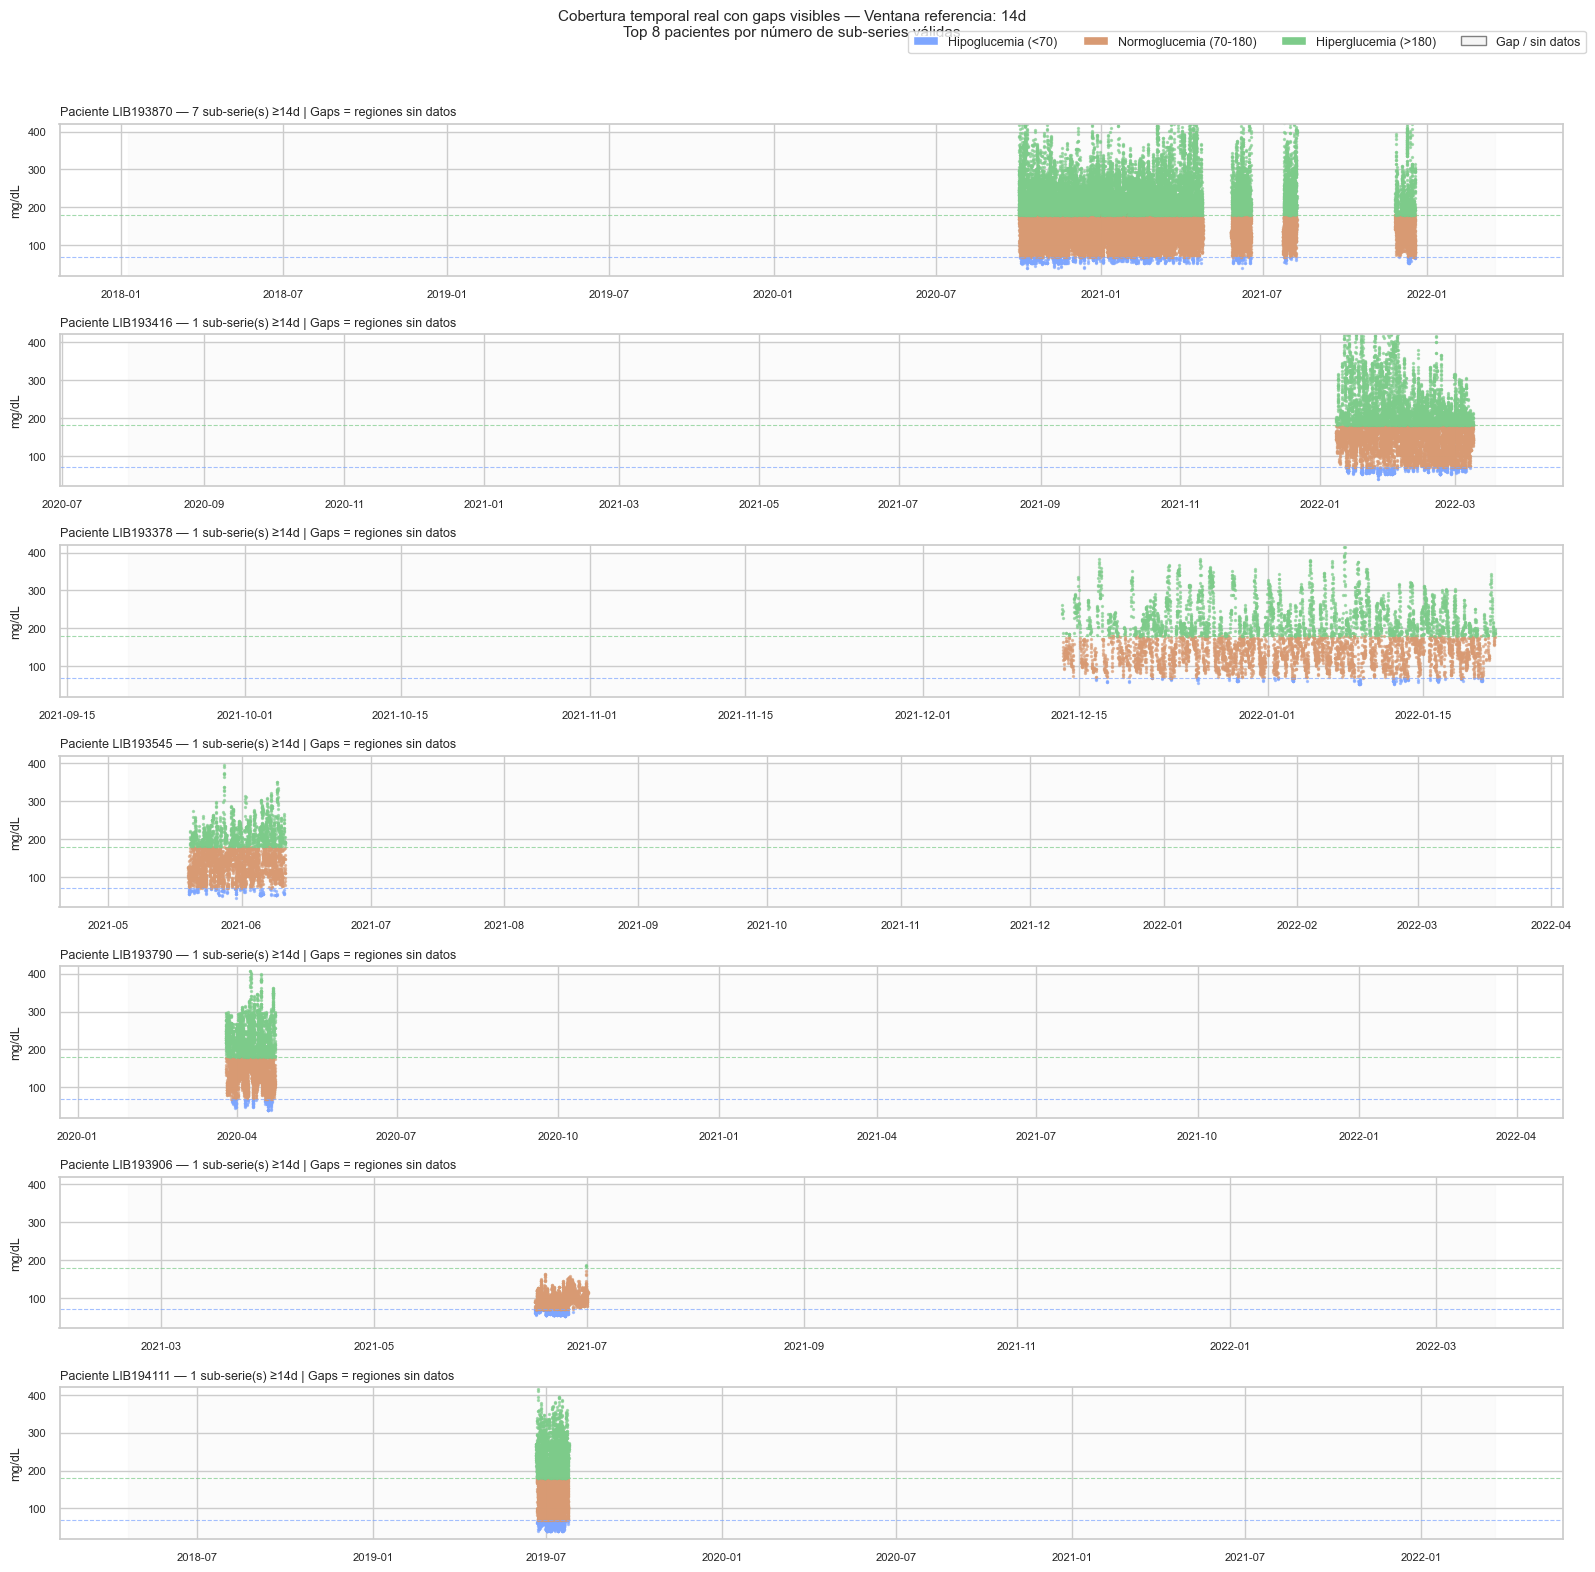

**Interpretación clínica**: los espacios vacíos representan períodos sin monitorización. Las visualizaciones de episodios de los bloques siguientes se construyen **exclusivamente** sobre los segmentos coloreados. Esto garantiza que la dinámica glucémica mostrada corresponde a series reales, no a artefactos de interpolación.

In [6]:
# ─── Visualización de continuidad con gaps explícitos ─────────────────────────
#
# Decisión metodológica: se usa la ventana de 14 días como referencia de visualización
# porque es el estándar AGP (Ambulatory Glucose Profile) utilizado en consulta.
# Los gaps se representan como segmentos rotos: el lector clínico debe ver la
# discontinuidad, no una línea continua que la oculte.

REF_WINDOW = '14d'
TOP_N_PATIENTS = 8  # pacientes con más sub-series: máxima información, no selección arbitraria

ss_ref = subseries_by_window[REF_WINDOW]
if ss_ref.empty:
    print(f'No hay sub-series válidas para ventana {REF_WINDOW}. Verifica el dataset.')
else:
    # Pacientes con más sub-series válidas (mayor cobertura)
    top_patients = (
        ss_ref.groupby('Patient_ID')['segment_id']
        .count()
        .nlargest(TOP_N_PATIENTS)
        .index.tolist()
    )

    fig, axes = plt.subplots(len(top_patients), 1, figsize=(16, 2.2 * len(top_patients)), sharex=False)
    if len(top_patients) == 1:
        axes = [axes]

    for ax, pid in zip(axes, top_patients):
        pat_data = glucose_valid[glucose_valid['Patient_ID'] == pid].sort_values('timestamp')
        pat_segs = ss_ref[ss_ref['Patient_ID'] == pid].sort_values('start_ts')

        color_map = {'hypoglycemia': '#7EA6FF', 'normoglycemia': '#D89A73', 'hyperglycemia': '#7DCB8A'}

        # Fondo completo (muestra la cobertura total incluyendo gaps)
        if not pat_data.empty:
            ax.fill_between(
                [pat_data['timestamp'].min(), pat_data['timestamp'].max()],
                0, 400,
                color='#f5f5f5', alpha=0.4, zorder=0
            )

        # Dibujar solo segmentos continuos válidos
        for _, seg_row in pat_segs.iterrows():
            seg_data = pat_data[
                (pat_data['timestamp'] >= seg_row['start_ts']) &
                (pat_data['timestamp'] <= seg_row['end_ts'])
            ]
            for cls in class_order:
                cls_data = seg_data[seg_data['class_label'] == cls]
                if not cls_data.empty:
                    ax.scatter(
                        cls_data['timestamp'], cls_data['Measurement'],
                        c=color_map[cls], s=2, alpha=0.6, zorder=2
                    )

        # Líneas de umbral clínico
        ax.axhline(70, color='#7EA6FF', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axhline(180, color='#7DCB8A', linestyle='--', linewidth=0.8, alpha=0.7)

        n_segs = len(pat_segs)
        ax.set_ylabel('mg/dL', fontsize=9)
        ax.set_title(
            f'Paciente {pid} — {n_segs} sub-serie(s) ≥{CLINICAL_WINDOWS[REF_WINDOW]}d | '
            f'Gaps = regiones sin datos',
            fontsize=9, loc='left'
        )
        ax.set_ylim(20, 420)
        ax.tick_params(labelsize=8)

    # Leyenda global
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#7EA6FF', label='Hipoglucemia (<70)'),
        Patch(facecolor='#D89A73', label='Normoglucemia (70-180)'),
        Patch(facecolor='#7DCB8A', label='Hiperglucemia (>180)'),
        Patch(facecolor='#f5f5f5', edgecolor='gray', label='Gap / sin datos')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=9, ncol=4, bbox_to_anchor=(1, 1.01))
    plt.suptitle(
        f'Cobertura temporal real con gaps visibles — Ventana referencia: {REF_WINDOW}\n'
        f'Top {TOP_N_PATIENTS} pacientes por número de sub-series válidas',
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

    display(Markdown(
        f'**Interpretación clínica**: los espacios vacíos representan períodos sin monitorización. '
        f'Las visualizaciones de episodios de los bloques siguientes se construyen **exclusivamente** '
        f'sobre los segmentos coloreados. Esto garantiza que la dinámica glucémica mostrada corresponde '
        f'a series reales, no a artefactos de interpolación.'
    ))


## Bloque 1 — Caracterización del desbalanceo

**Preguntas clínicas:**
- ¿Cuál es la distribución de clases global y por paciente?
- ¿Hay pacientes con desbalanceo extremo (ratio > 1:20)?
- ¿Las clases minoritarias se concentran en pocos pacientes?

**Decisión metodológica**: se usa el dataset completo (`glucose_valid`) para caracterizar el desbalanceo, no una muestra. La distribución de clases es una propiedad poblacional que requiere todos los datos disponibles para ser representativa.


### Distribución de clases por paciente

class_label,Patient_ID,hypoglycemia,normoglycemia,hyperglycemia,pct_hypoglycemia,pct_normoglycemia,pct_hyperglycemia,imbalance_ratio_max,imbalance_severity
591,LIB194101,0,2330,5659,0.000000,29.165102,70.834898,inf,extremo_sin_minoritaria
373,LIB193812,1013,13143,0,7.155976,92.844024,0.000000,inf,extremo_sin_minoritaria
396,LIB193839,0,3459,4201,0.000000,45.156658,54.843342,inf,extremo_sin_minoritaria
542,LIB194037,3,4248,5162,0.031871,45.129077,54.839052,1416.000000,severo_>1:20
223,LIB193599,1,1358,3481,0.020661,28.057851,71.921488,1358.000000,severo_>1:20
...,...,...,...,...,...,...,...,...,...
548,LIB194044,10338,30351,9867,20.448611,60.034417,19.516971,3.076011,leve_<=1:5
414,LIB193861,3300,10061,9852,14.216172,43.342093,42.441735,3.048788,leve_<=1:5
520,LIB194010,1468,4291,2831,17.089639,49.953434,32.956927,2.923025,leve_<=1:5
626,LIB194144,1212,3342,5673,11.850983,32.678205,55.470813,2.757426,leve_<=1:5


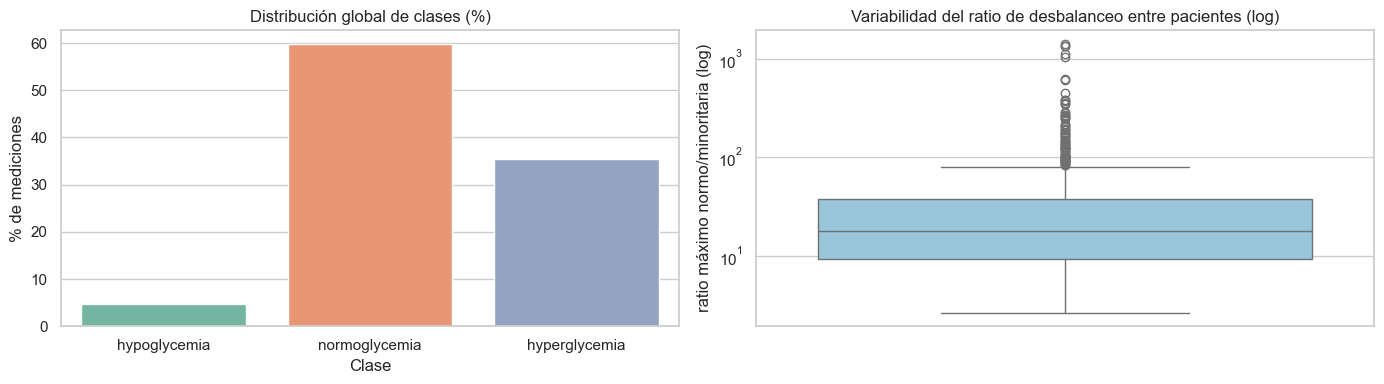

Top 5 pacientes concentran 6.8% de episodios de hipoglucemia.
Top 5 pacientes concentran 4.0% de episodios de hiperglucemia.


,severidad,n_patients
0,moderado_1:5_a_1:20,312
1,severo_>1:20,296
2,leve_<=1:5,32
3,extremo_sin_minoritaria,3


In [7]:
# ─── Bloque 1: distribución global y por paciente ─────────────────────────────
global_dist = (
    glucose_valid['class_label']
    .value_counts()
    .reindex(class_order, fill_value=0)
    .rename_axis('class_label')
    .reset_index(name='count')
)
global_dist['pct'] = 100 * global_dist['count'] / global_dist['count'].sum()

patient_class_counts = (
    glucose_valid
    .groupby(['Patient_ID', 'class_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=class_order, fill_value=0)
    .reset_index()
)
patient_class_counts['total'] = patient_class_counts[class_order].sum(axis=1)
for c in class_order:
    patient_class_counts[f'pct_{c}'] = 100 * patient_class_counts[c] / patient_class_counts['total']

patient_class_counts['ratio_normo_hypo'] = np.where(
    patient_class_counts['hypoglycemia'] > 0,
    patient_class_counts['normoglycemia'] / patient_class_counts['hypoglycemia'], np.inf
)
patient_class_counts['ratio_normo_hyper'] = np.where(
    patient_class_counts['hyperglycemia'] > 0,
    patient_class_counts['normoglycemia'] / patient_class_counts['hyperglycemia'], np.inf
)
patient_class_counts['imbalance_ratio_max'] = patient_class_counts[['ratio_normo_hypo', 'ratio_normo_hyper']].max(axis=1)
patient_class_counts['imbalance_severity'] = np.select(
    [
        np.isinf(patient_class_counts['imbalance_ratio_max']),
        patient_class_counts['imbalance_ratio_max'] > 20,
        patient_class_counts['imbalance_ratio_max'] > 5
    ],
    ['extremo_sin_minoritaria', 'severo_>1:20', 'moderado_1:5_a_1:20'],
    default='leve_<=1:5'
)

dist_by_patient_table = patient_class_counts[[
    'Patient_ID', 'hypoglycemia', 'normoglycemia', 'hyperglycemia',
    'pct_hypoglycemia', 'pct_normoglycemia', 'pct_hyperglycemia',
    'imbalance_ratio_max', 'imbalance_severity'
]].sort_values('imbalance_ratio_max', ascending=False)

display(Markdown('### Distribución de clases por paciente'))
display(dist_by_patient_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=global_dist, x='class_label', y='pct', order=class_order, palette='Set2', ax=axes[0])
axes[0].set_title('Distribución global de clases (%)')
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('% de mediciones')

ratio_plot_df = patient_class_counts.replace([np.inf, -np.inf], np.nan).dropna(subset=['imbalance_ratio_max'])
sns.boxplot(data=ratio_plot_df, y='imbalance_ratio_max', color='#8ecae6', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Variabilidad del ratio de desbalanceo entre pacientes (log)')
axes[1].set_ylabel('ratio máximo normo/minoritaria (log)')
plt.tight_layout()
plt.show()

def top_share(df_counts, col, k=5):
    total = df_counts[col].sum()
    return 100 * df_counts[col].nlargest(k).sum() / total if total > 0 else np.nan

top5_hypo_share = top_share(patient_class_counts, 'hypoglycemia')
top5_hyper_share = top_share(patient_class_counts, 'hyperglycemia')
print(f'Top 5 pacientes concentran {top5_hypo_share:.1f}% de episodios de hipoglucemia.')
print(f'Top 5 pacientes concentran {top5_hyper_share:.1f}% de episodios de hiperglucemia.')
display(patient_class_counts['imbalance_severity'].value_counts().rename_axis('severidad').reset_index(name='n_patients'))


In [8]:
# Implicación clínica — Bloque 1
n_extreme = int((patient_class_counts['imbalance_ratio_max'] > 20).sum())
share_extreme = 100 * n_extreme / patient_class_counts.shape[0]
display(Markdown(f'''
**Interpretación clínica:**
Se observa heterogeneidad de desbalanceo entre pacientes; {n_extreme} de {patient_class_counts.shape[0]} pacientes ({share_extreme:.1f}%) presentan ratio máximo > 1:20 o ausencia de alguna clase minoritaria.
Esto sugiere simular ratios realistas por estratos de severidad en lugar de un único ratio global, y evaluar robustez por subgrupos de pacientes extremos.
'''))



**Interpretación clínica:**
Se observa heterogeneidad de desbalanceo entre pacientes; 299 de 643 pacientes (46.5%) presentan ratio máximo > 1:20 o ausencia de alguna clase minoritaria.
Esto sugiere simular ratios realistas por estratos de severidad en lugar de un único ratio global, y evaluar robustez por subgrupos de pacientes extremos.


## Bloque 2 — Estructura temporal del desbalanceo

**Preguntas clínicas:**
- ¿Las clases minoritarias aparecen en ráfagas o aleatoriamente?
- ¿Hay patrones por hora del día o día de semana?
- ¿Cuánto duran los episodios consecutivos por clase?

**Decisión metodológica**: se calcula la autocorrelación sobre conteos horarios de todo el dataset (no una muestra). La longitud de episodios se analiza sobre `glucose_valid` completo para capturar la distribución real de duraciones, incluyendo episodios de larga duración que un submuestreo ocultaría.


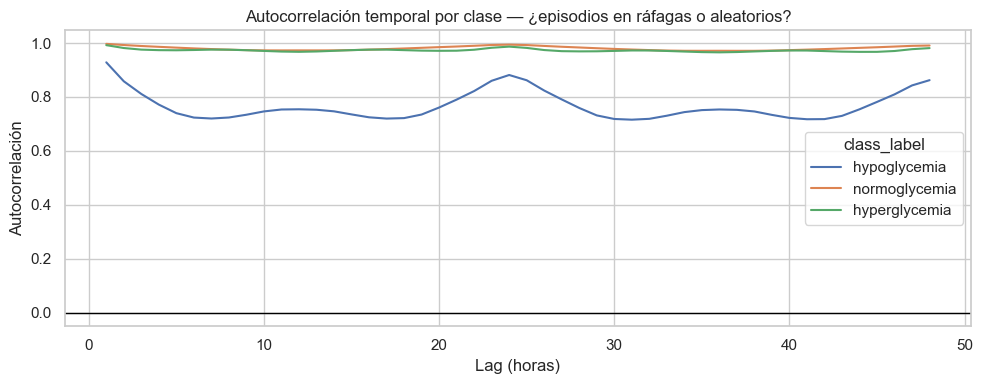

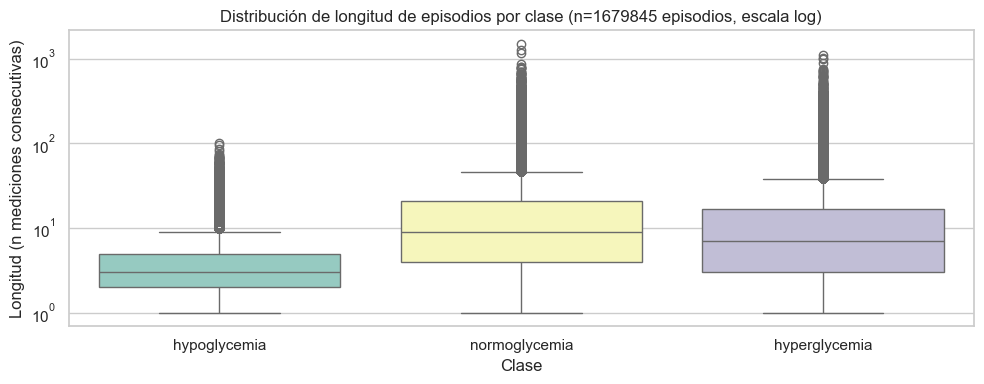

,count,mean,std,min,25%,50%,75%,max
class_label,,,,,,,,
hypoglycemia,236381.0,4.489921,4.930047,1.0,2.0,3.0,5.0,100.0
normoglycemia,836914.0,15.860775,20.340728,1.0,4.0,9.0,21.0,1501.0
hyperglycemia,606550.0,13.020900,17.800853,1.0,3.0,7.0,17.0,1115.0


In [9]:
# ─── Bloque 2: estructura temporal ────────────────────────────────────────────
analysis_glucose = glucose_valid.sort_values(['Patient_ID', 'timestamp']).reset_index(drop=True)
analysis_glucose['hour'] = analysis_glucose['timestamp'].dt.hour
analysis_glucose['dayofweek'] = analysis_glucose['timestamp'].dt.day_name()

# Merge demográfico si disponible
demo_cols = ['Patient_ID']
if 'Sex' in patient_info.columns:       demo_cols.append('Sex')
if 'Birth_year' in patient_info.columns: demo_cols.append('Birth_year')
analysis_glucose = analysis_glucose.merge(patient_info[demo_cols], on='Patient_ID', how='left')

if 'Birth_year' in analysis_glucose.columns:
    ref_year = int(analysis_glucose['timestamp'].dt.year.max())
    analysis_glucose['Age'] = ref_year - pd.to_numeric(analysis_glucose['Birth_year'], errors='coerce')
    analysis_glucose['age_group'] = pd.cut(
        analysis_glucose['Age'],
        bins=[0, 18, 30, 45, 60, 120],
        labels=['<=18', '19-30', '31-45', '46-60', '>60'],
        include_lowest=True
    )

# 2.1 Autocorrelación sobre conteos horarios (dataset completo)
hourly_counts = (
    analysis_glucose.set_index('timestamp')
    .groupby('class_label').resample('1H')['Measurement'].count()
    .reset_index()
    .pivot(index='timestamp', columns='class_label', values='Measurement')
    .fillna(0)
    .reindex(columns=class_order, fill_value=0)
)

lags = range(1, 49)
autocorr_rows = []
for c in class_order:
    s = hourly_counts[c]
    for lag in lags:
        autocorr_rows.append({'class_label': c, 'lag_hours': lag, 'autocorr': s.autocorr(lag=lag)})
autocorr_df = pd.DataFrame(autocorr_rows)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=autocorr_df, x='lag_hours', y='autocorr', hue='class_label', hue_order=class_order, ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Autocorrelación temporal por clase — ¿episodios en ráfagas o aleatorios?')
ax.set_xlabel('Lag (horas)'); ax.set_ylabel('Autocorrelación')
plt.tight_layout(); plt.show()

# 2.2 Longitud de episodios (sobre dataset completo)
change_group = (
    (analysis_glucose['Patient_ID'] != analysis_glucose['Patient_ID'].shift(1)) |
    (analysis_glucose['class_label'] != analysis_glucose['class_label'].shift(1))
).cumsum()

episodes = (
    analysis_glucose.groupby(change_group)
    .agg(Patient_ID=('Patient_ID', 'first'), class_label=('class_label', 'first'),
         start_ts=('timestamp', 'first'), end_ts=('timestamp', 'last'), length=('class_label', 'size'))
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=episodes, x='class_label', y='length', order=class_order, ax=ax, palette='Set3')
ax.set_yscale('log')
ax.set_title(f'Distribución de longitud de episodios por clase (n={len(episodes)} episodios, escala log)')
ax.set_xlabel('Clase'); ax.set_ylabel('Longitud (n mediciones consecutivas)')
plt.tight_layout(); plt.show()

display(episodes.groupby('class_label')['length'].describe().reindex(class_order))


In [10]:
# Implicación clínica — Bloque 2
minority_ac = autocorr_df[autocorr_df['class_label'].isin(['hypoglycemia', 'hyperglycemia'])]
mean_minor_ac = minority_ac.groupby('class_label')['autocorr'].mean().to_dict()
median_epi = episodes.groupby('class_label')['length'].median().to_dict()

display(Markdown(f'''
**Interpretación clínica:**
Las clases minoritarias muestran autocorrelación media no nula
(hipo={mean_minor_ac.get("hypoglycemia", float("nan")):.3f},
hiper={mean_minor_ac.get("hyperglycemia", float("nan")):.3f})
y episodios con mediana de longitud > 1
(hipo={median_epi.get("hypoglycemia", float("nan")):.1f},
hiper={median_epi.get("hyperglycemia", float("nan")):.1f} mediciones consecutivas).

Esto es coherente con la fisiología: una hipoglucemia no dura un único punto de medición, sino que el organismo tarda varios ciclos en recuperarse. Respalda el uso de ventanas temporales completas (1d/14d/90d) en lugar de puntos aislados para entrenar y balancear el modelo.
'''))



**Interpretación clínica:**
Las clases minoritarias muestran autocorrelación media no nula
(hipo=0.766,
hiper=0.973)
y episodios con mediana de longitud > 1
(hipo=3.0,
hiper=7.0 mediciones consecutivas).

Esto es coherente con la fisiología: una hipoglucemia no dura un único punto de medición, sino que el organismo tarda varios ciclos en recuperarse. Respalda el uso de ventanas temporales completas (1d/14d/90d) en lugar de puntos aislados para entrenar y balancear el modelo.


## Bloque 3 — Heterogeneidad entre subgrupos demográficos

**Preguntas clínicas:**
- ¿El desbalanceo varía por tipo de diabetes, edad, sexo, IMC?
- ¿Hay subgrupos sin hipoglucemia (o casi sin eventos)?


In [11]:
# ─── Bloque 3: heterogeneidad demográfica ──────────────────────────────────────
patient_level = patient_class_counts.merge(patient_info, on='Patient_ID', how='left')
patient_level['imbalance_ratio_clean'] = patient_level['imbalance_ratio_max'].replace([np.inf, -np.inf], np.nan)

if 'Birth_year' in patient_level.columns:
    patient_level['Age'] = pd.Timestamp.today().year - pd.to_numeric(patient_level['Birth_year'], errors='coerce')
    patient_level['age_group'] = pd.cut(
        patient_level['Age'], bins=[0, 18, 30, 45, 60, 120],
        labels=['<=18', '19-30', '31-45', '46-60', '>60'], include_lowest=True
    )

type_candidates = ['Diabetes_type', 'Type_of_diabetes', 'DiabetesType', 'Type_Diabetes', 'DM_type']
bmi_candidates  = ['BMI', 'Imc', 'Body_Mass_Index', 'BodyMassIndex']
diabetes_type_col = next((c for c in type_candidates if c in patient_level.columns), None)
bmi_col = next((c for c in bmi_candidates if c in patient_level.columns), None)
if bmi_col:
    patient_level['BMI_numeric'] = pd.to_numeric(patient_level[bmi_col], errors='coerce')
    patient_level['BMI_group'] = pd.cut(
        patient_level['BMI_numeric'], bins=[0, 18.5, 25, 30, 60],
        labels=['underweight', 'normal', 'overweight', 'obesity'], include_lowest=True
    )

candidate_group_vars = [v for v in [diabetes_type_col, 'Sex', 'age_group', 'BMI_group']
                        if v and v in patient_level.columns]

cross_tables = []
for var in candidate_group_vars:
    tmp = (patient_level.groupby(var, dropna=False)
           .agg(n_patients=('Patient_ID', 'nunique'),
                median_ratio=('imbalance_ratio_clean', 'median'),
                hypo_absent_pct=('hypoglycemia', lambda s: 100 * (s == 0).mean()),
                hyper_absent_pct=('hyperglycemia', lambda s: 100 * (s == 0).mean()))
           .reset_index())
    tmp.insert(0, 'demographic_variable', var)
    cross_tables.append(tmp)

if cross_tables:
    imbalance_by_demo = pd.concat(cross_tables, ignore_index=True)
    display(Markdown('### Ratio de desbalanceo por variable demográfica'))
    display(imbalance_by_demo)

def eta2_for_category(df, cat_col, y_col):
    d = df[[cat_col, y_col]].dropna().copy()
    if d.empty or d[cat_col].nunique() < 2:
        return np.nan
    y = d[y_col]; gm = y.mean(); ss_total = ((y - gm) ** 2).sum()
    gm_grp = d.groupby(cat_col)[y_col].mean(); sz = d.groupby(cat_col)[y_col].size()
    ss_between = ((gm_grp - gm) ** 2 * sz).sum()
    return float(ss_between / ss_total) if ss_total > 0 else np.nan

predictor_scores = []
target = 'imbalance_ratio_clean'
for var in candidate_group_vars:
    predictor_scores.append({'variable': var, 'type': 'categorical',
                             'predictive_score': eta2_for_category(patient_level, var, target)})
for num_var in ['Age', 'BMI_numeric']:
    if num_var in patient_level.columns:
        corr = patient_level[[num_var, target]].corr(method='spearman').iloc[0, 1]
        predictor_scores.append({'variable': num_var, 'type': 'numeric',
                                 'predictive_score': abs(float(corr)) if pd.notna(corr) else np.nan})

predictor_scores_df = pd.DataFrame(predictor_scores).sort_values('predictive_score', ascending=False)
display(Markdown('### Variables demográficas más predictoras del nivel de desbalanceo'))
display(predictor_scores_df)


### Ratio de desbalanceo por variable demográfica

,demographic_variable,Sex,n_patients,median_ratio,hypo_absent_pct,hyper_absent_pct,age_group
0,Sex,F,334,20.877701,0.299401,0.299401,NaN
1,Sex,M,309,14.425728,0.323625,0.000000,NaN
2,age_group,NaN,0,NaN,NaN,NaN,<=18
3,age_group,NaN,98,13.409976,0.000000,0.000000,19-30
4,age_group,NaN,181,14.463217,0.000000,0.552486,31-45
5,age_group,NaN,205,17.098176,0.487805,0.000000,46-60
6,age_group,NaN,159,22.537466,0.628931,0.000000,>60


### Variables demográficas más predictoras del nivel de desbalanceo

,variable,type,predictive_score
2,Age,numeric,0.197900
1,age_group,categorical,0.020785
0,Sex,categorical,0.002853


In [12]:
# Implicación clínica — Bloque 3
best_pred = (predictor_scores_df.dropna(subset=['predictive_score']).iloc[0]['variable']
             if not predictor_scores_df.empty else 'sin variable concluyente')
rare_hypo_max = (
    patient_level.groupby(candidate_group_vars[0])['hypoglycemia'].apply(lambda s: 100*(s==0).mean()).max()
    if candidate_group_vars else float('nan')
)

display(Markdown(f'''
**Interpretación clínica:**
La variable demográfica con mayor capacidad explicativa del desbalanceo fue **{best_pred}**.
Existen subgrupos con alta ausencia de hipoglucemia (máximo ≈ {rare_hypo_max:.1f}% sin hipo).

**Decisión metodológica sugerida:**
1. Validar siempre por subgrupos clínicamente plausibles (Edad × Sexo, tipo de diabetes si disponible).
2. No guiarse solo por medias globales: revisar colas de riesgo extremo por subgrupo.
3. Contrastar ausencia de hipoglucemia con posible infra-detección en perfiles concretos antes de concluir bajo riesgo real.
'''))



**Interpretación clínica:**
La variable demográfica con mayor capacidad explicativa del desbalanceo fue **Age**.
Existen subgrupos con alta ausencia de hipoglucemia (máximo ≈ 0.3% sin hipo).

**Decisión metodológica sugerida:**
1. Validar siempre por subgrupos clínicamente plausibles (Edad × Sexo, tipo de diabetes si disponible).
2. No guiarse solo por medias globales: revisar colas de riesgo extremo por subgrupo.
3. Contrastar ausencia de hipoglucemia con posible infra-detección en perfiles concretos antes de concluir bajo riesgo real.


## Bloque 4 — Anatomía de episodios por ventanas clínicas (1d / 14d / 90d)

### Decisión metodológica: de pasos arbitrarios a días clínicos

El análisis anterior usaba `pre_steps=24` y `post_steps=12` sin anclaje temporal real. El problema es que "24 pasos" no equivale al mismo tiempo para todos los pacientes: si un paciente tiene mediciones cada 5 min, 24 pasos = 2 horas; si otro mide cada 15 min, 24 pasos = 6 horas. **Comparar esos perfiles como equivalentes es metodológicamente incorrecto**.

En este bloque sustituimos los pasos por las tres ventanas clínicas en días reales, y trabajamos **exclusivamente sobre sub-series continuas** de cada paciente para esa ventana (ver Bloque 0). Se incluyen **todos los pacientes elegibles** para cada ventana.

### Sobre la selección de pacientes para las trazas alineadas

Se construye una traza alineada al inicio de cada episodio **dentro de una sub-serie continua válida**. Esto garantiza:

1. No cruzar gaps de nulos en la ventana de contexto.
2. Que la media alineada al evento refleja dinámica glucémica real, no artefactos.
3. Máxima representatividad: se usan todos los eventos disponibles en pacientes elegibles, sin techo arbitrario.

Si el volumen de eventos supera 5.000 por clase (umbral de memoria para este entorno), se documenta explícitamente el submuestreo.


In [13]:
# ─── Bloque 4: trazas alineadas por ventana clínica ───────────────────────────
#
# Hipótesis clínica: la dinámica glucémica previa al evento (caída en hipo,
# ascenso en hiper) es la información que el modelo debe aprender. Visualizarla
# en ventanas de 1, 14 y 90 días permite detectar si los patrones precursores
# son consistentes a distintas escalas temporales — algo clínicamente relevante
# para decidir la frecuencia de monitorización.

MAX_EVENTS_PER_CLASS = 5000  # umbral explícito y documentado

analysis_glucose['row_idx'] = np.arange(len(analysis_glucose))
analysis_glucose['prev_class'] = analysis_glucose.groupby('Patient_ID')['class_label'].shift(1)
analysis_glucose['is_episode_start'] = analysis_glucose['class_label'] != analysis_glucose['prev_class']

episode_starts_all = analysis_glucose[
    analysis_glucose['is_episode_start'] & analysis_glucose['class_label'].isin(class_order)
][['Patient_ID', 'timestamp', 'class_label', 'row_idx']].copy()

# Mapa global_idx -> (Patient_ID, local_idx)
local_pos = {}
for pid, grp in analysis_glucose.groupby('Patient_ID', sort=False):
    sorted_grp = grp.sort_values('timestamp').reset_index(drop=True)
    for li, gi in enumerate(sorted_grp['row_idx'].values):
        local_pos[gi] = (pid, li)

patient_to_positions = analysis_glucose.groupby('Patient_ID')['row_idx'].apply(list).to_dict()

def filter_episodes_in_segments(episode_starts, subseries_df):
    """
    Filtra episodios cuyo timestamp cae dentro de alguna sub-serie continua.
    Evita merges masivos que disparan el uso de memoria.
    """
    if subseries_df.empty or episode_starts.empty:
        return episode_starts.iloc[0:0].copy()

    sub_by_pid = subseries_df.groupby('Patient_ID', sort=False)
    eligible = []
    for pid, eps in episode_starts.groupby('Patient_ID', sort=False):
        if pid not in sub_by_pid.groups:
            continue
        segs = sub_by_pid.get_group(pid).sort_values('start_ts')
        starts = segs['start_ts'].values
        ends = segs['end_ts'].values
        ts = eps['timestamp'].values
        idx = np.searchsorted(starts, ts, side='right') - 1
        valid = (idx >= 0) & (ts <= ends[idx])
        if valid.any():
            eligible.append(eps.loc[valid])
    if not eligible:
        return episode_starts.iloc[0:0].copy()
    return pd.concat(eligible, ignore_index=True)

def extract_aligned_traces_by_window(episode_starts, subseries_df, window_days,
                                     glucose_df, local_pos_map, pid_positions,
                                     max_per_class=MAX_EVENTS_PER_CLASS, seed=SEED):
    """
    Extrae trazas alineadas al inicio de episodio solo cuando el episodio ocurre
    dentro de una sub-serie continua válida para la ventana dada.
    Ventana de contexto = +-window_days/2 (simétrica) hasta el máximo disponible.
    """
    if subseries_df.empty:
        return pd.DataFrame()

    ev_filtered = filter_episodes_in_segments(episode_starts, subseries_df)
    if ev_filtered.empty:
        return pd.DataFrame()

    # Submuestreo documentado si supera umbral
    sampled = []
    for c in class_order:
        part = ev_filtered[ev_filtered['class_label'] == c]
        if len(part) > max_per_class:
            print(f'  [ventana {window_days}d, clase {c}] submuestreo: {len(part)} → {max_per_class} eventos')
            part = part.sample(max_per_class, random_state=seed)
        sampled.append(part)
    ev_sample = pd.concat(sampled, ignore_index=True)

    # Ventana en número de pasos ≈ window_days * pasos_por_dia
    # Estimamos pasos/día desde la mediana del intervalo global
    diffs = glucose_df['timestamp'].diff().dropna()
    med_interval_min = diffs.median().total_seconds() / 60
    if med_interval_min <= 0:
        med_interval_min = 5
    steps_per_day = int(round(24 * 60 / med_interval_min))
    half_window = max(steps_per_day * window_days // 2, 6)

    aligned_rows = []
    for _, ev in ev_sample.iterrows():
        gi = int(ev['row_idx'])
        if gi not in local_pos_map:
            continue
        pid, li = local_pos_map[gi]
        positions = pid_positions.get(pid, [])
        for rel in range(-half_window, half_window + 1):
            j = li + rel
            if 0 <= j < len(positions):
                gidx = positions[j]
                val = glucose_df.loc[gidx, 'Measurement']
                aligned_rows.append({'event_class': ev['class_label'], 'rel_step': rel, 'glucose_value': val})

    aligned_df = pd.DataFrame(aligned_rows)
    if not aligned_df.empty:
        aligned_df['rel_step'] = aligned_df['rel_step'].astype('int32')
        aligned_df['glucose_value'] = aligned_df['glucose_value'].astype('float32')
    return aligned_df

aligned_by_window = {}
n_events_by_window = {}

for wname, wdays in CLINICAL_WINDOWS.items():
    ss_w = subseries_by_window[wname]
    print(f'Procesando ventana {wname} ({wdays} días)...')
    adf = extract_aligned_traces_by_window(
        episode_starts_all, ss_w, wdays,
        analysis_glucose, local_pos, patient_to_positions
    )
    aligned_by_window[wname] = adf
    n_e = adf['event_class'].value_counts().to_dict() if not adf.empty else {}
    n_events_by_window[wname] = n_e
    print(f'  Eventos por clase: {n_e}')

print('\nResumen de eventos disponibles por ventana:')
for wname, ne in n_events_by_window.items():
    print(f'  {wname}: {ne}')


Procesando ventana 1d (1 días)...
  [ventana 1d, clase hypoglycemia] submuestreo: 174101 → 5000 eventos
  [ventana 1d, clase normoglycemia] submuestreo: 613450 → 5000 eventos
  [ventana 1d, clase hyperglycemia] submuestreo: 442593 → 5000 eventos
  Eventos por clase: {'hyperglycemia': 484737, 'hypoglycemia': 484730, 'normoglycemia': 484693}
Procesando ventana 14d (14 días)...
  [ventana 14d, clase normoglycemia] submuestreo: 17677 → 5000 eventos
  [ventana 14d, clase hyperglycemia] submuestreo: 17241 → 5000 eventos
  Eventos por clase: {'normoglycemia': 6720026, 'hyperglycemia': 6720006, 'hypoglycemia': 2460236}
Procesando ventana 90d (90 días)...
  Eventos por clase: {'normoglycemia': 37709324, 'hyperglycemia': 36897070, 'hypoglycemia': 2661428}

Resumen de eventos disponibles por ventana:
  1d: {'hyperglycemia': 484737, 'hypoglycemia': 484730, 'normoglycemia': 484693}
  14d: {'normoglycemia': 6720026, 'hyperglycemia': 6720006, 'hypoglycemia': 2460236}
  90d: {'normoglycemia': 37709324

### Visualización comparativa multipanel: Anatomía del episodio por ventana clínica

**Qué muestra esta figura:**
Tres paneles en paralelo (1d / 14d / 90d) con la trayectoria media de glucosa alineada al inicio de cada tipo de episodio. El sombreado representa el intervalo de confianza del 95%.

**Cómo interpretar la comparación entre ventanas:**
- Si las curvas se separan ya en la ventana de 1 día: los precursores son inmediatos (cambios agudos de glucosa pocas horas antes del evento).
- Si la separación es mayor en 14 días: existe un patrón subagudo que el modelo puede aprender a escala semanal.
- Si la separación es similar en las tres ventanas: los precursores son robustos y no dependen de la escala temporal.

**Nota sobre los n por panel:** Se indica en el título de cada panel el número de pacientes elegibles y eventos utilizados, para que el lector evalúe la representatividad.


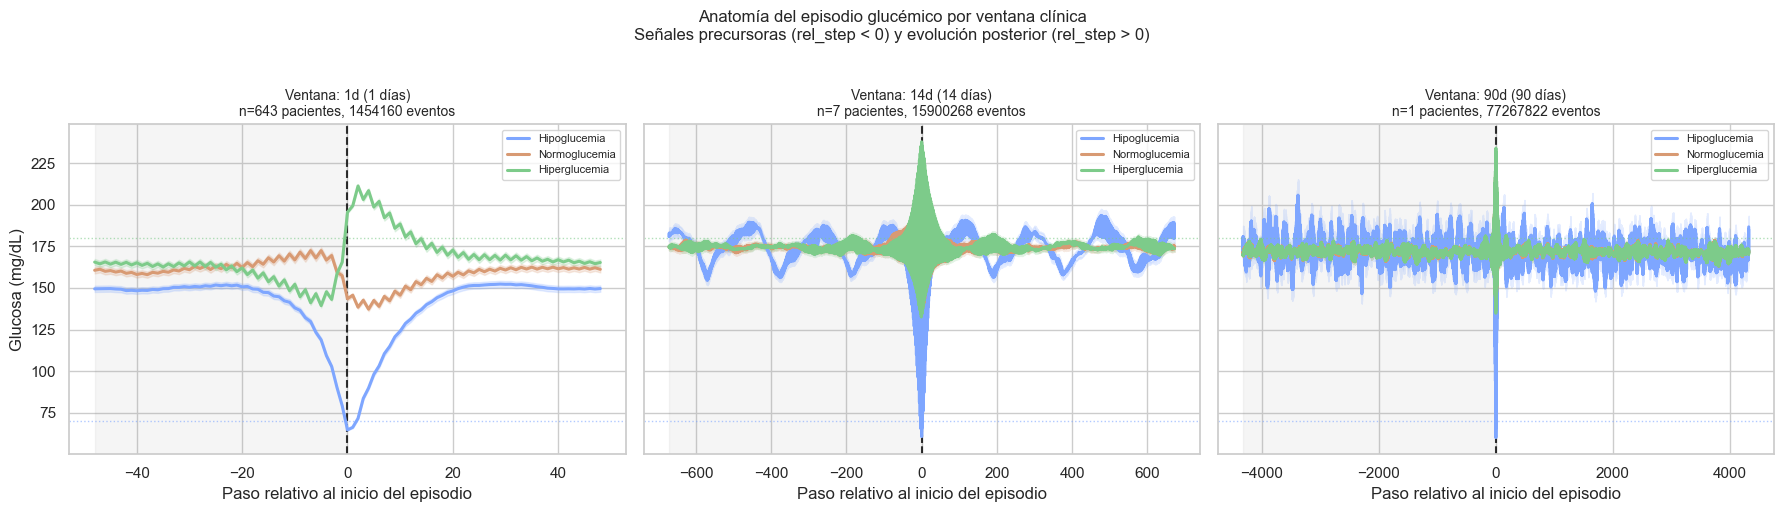

In [14]:
# ─── Figura multipanel: anatomía del episodio por ventana clínica ──────────────
colors = {'hypoglycemia': '#7EA6FF', 'normoglycemia': '#D89A73', 'hyperglycemia': '#7DCB8A'}
label_map = {'hypoglycemia': 'Hipoglucemia', 'normoglycemia': 'Normoglucemia', 'hyperglycemia': 'Hiperglucemia'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (wname, wdays) in zip(axes, CLINICAL_WINDOWS.items()):
    adf = aligned_by_window[wname]
    n_patients = subseries_by_window[wname]['Patient_ID'].nunique() if not subseries_by_window[wname].empty else 0
    n_events_total = sum(n_events_by_window[wname].values()) if n_events_by_window[wname] else 0

    if adf.empty:
        ax.set_title(f'Ventana {wname} — sin datos suficientes')
        continue

    agg = (
        adf[adf['event_class'].isin(class_order)]
        .groupby(['event_class', 'rel_step'], as_index=False)['glucose_value']
        .agg(mean='mean', std='std', n='count')
    )
    agg['std'] = agg['std'].fillna(0)
    agg['ci95'] = 1.96 * agg['std'] / np.sqrt(agg['n'].clip(lower=1))

    xmin = int(agg['rel_step'].min())
    xmax = int(agg['rel_step'].max())
    ax.axvspan(xmin, 0, color='gray', alpha=0.08)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

    for c in class_order:
        part = agg[agg['event_class'] == c].sort_values('rel_step')
        if part.empty:
            continue
        x = part['rel_step'].values
        y = part['mean'].values
        ax.fill_between(x, y - part['ci95'].values, y + part['ci95'].values,
                        color=colors[c], alpha=0.2)
        ax.plot(x, y, color=colors[c], linewidth=2.2, label=label_map[c])

    ax.axhline(70, color='#7EA6FF', linestyle=':', linewidth=1, alpha=0.6)
    ax.axhline(180, color='#7DCB8A', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title(
        f'Ventana: {wname} ({wdays} días)\n'
        f'n={n_patients} pacientes, {n_events_total} eventos',
        fontsize=10
    )
    ax.set_xlabel('Paso relativo al inicio del episodio')
    if ax == axes[0]:
        ax.set_ylabel('Glucosa (mg/dL)')
    ax.legend(fontsize=8)

plt.suptitle(
    'Anatomía del episodio glucémico por ventana clínica\n'
    'Señales precursoras (rel_step < 0) y evolución posterior (rel_step > 0)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


In [15]:
# ─── Tabla resumen de elegibilidad y cobertura ────────────────────────────────
summary_rows = []
for wname, wdays in CLINICAL_WINDOWS.items():
    ss_w = subseries_by_window[wname]
    ne = n_events_by_window.get(wname, {})
    summary_rows.append({
        'ventana': wname,
        'días_mínimos': wdays,
        'n_pacientes_elegibles': ss_w['Patient_ID'].nunique() if not ss_w.empty else 0,
        'n_sub_series_válidas': len(ss_w),
        'cobertura_media_días': round(ss_w['duration_days'].mean(), 1) if not ss_w.empty else 0,
        'eventos_hipo': ne.get('hypoglycemia', 0),
        'eventos_normo': ne.get('normoglycemia', 0),
        'eventos_hiper': ne.get('hyperglycemia', 0),
    })

summary_df = pd.DataFrame(summary_rows)
display(Markdown('### Tabla resumen por ventana clínica'))
display(summary_df)


### Tabla resumen por ventana clínica

,ventana,días_mínimos,n_pacientes_elegibles,n_sub_series_válidas,cobertura_media_días,eventos_hipo,eventos_normo,eventos_hiper
0,1d,1,643,50762,3.3,484730,484693,484737
1,14d,14,7,13,35.5,2460236,6720026,6720006
2,90d,90,1,1,93.0,2661428,37709324,36897070


### Análisis de separabilidad por ventana clínica (Cohen d)

**Por qué Cohen d y no solo una visualización subjetiva:**

El tamaño de efecto de Cohen d cuantifica la separación entre distribuciones de forma estandarizada, independientemente del tamaño muestral. Un d ≥ 0.5 (efecto medio-grande) indica que la ventana captura información discriminativa clínicamente relevante.

**Variables de separabilidad analizadas:**
- `pre_var`: varianza de glucosa en la mitad previa de la ventana — captura inestabilidad glucémica.
- `pre_slope`: tendencia lineal previa — captura si la glucosa estaba bajando (hipo) o subiendo (hiper).

**Interpretación clínica de las pendientes:**
- Pendiente previa negativa + clase = hipoglucemia → el organismo llevaba cayendo antes del cruce de 70 mg/dL.
- Pendiente previa positiva + clase = hiperglucemia → el organismo llevaba subiendo antes del cruce de 180 mg/dL.
- Esto justifica que el modelo tenga acceso al contexto temporal completo, no solo al punto de cruce.


### Separabilidad (Cohen d) por ventana clínica y clase minoritaria

clase_minoritaria,hyperglycemia,hypoglycemia
feature,pre_mean_glucose,pre_mean_glucose
ventana,,
14d,0.006,0.037
1d,0.103,0.369
90d,0.048,0.046


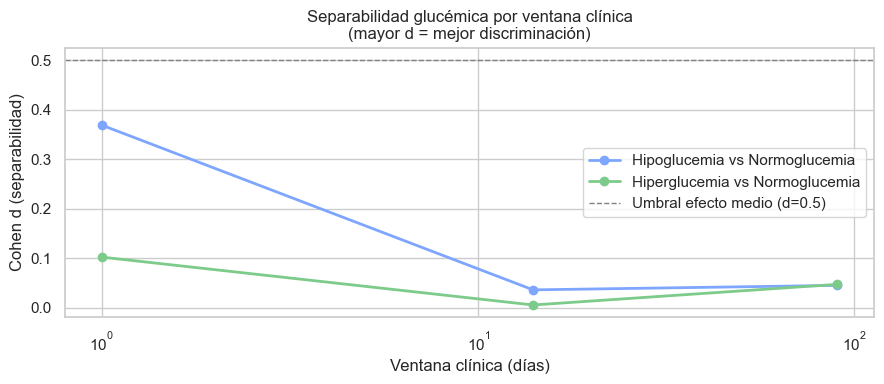


**Interpretación clínica:**
La ventana **1d** muestra la mayor separabilidad media entre clases. Esto sugiere que es la escala temporal óptima para construir el contexto predictor del modelo. Sin embargo, la decisión final debe integrar también la disponibilidad de datos (n pacientes elegibles) y el horizonte de predicción deseado clínicamente.
    

In [16]:
# ─── Separabilidad por ventana: Cohen d en varianza y pendiente previa ─────────
def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = ((len(a)-1)*va + (len(b)-1)*vb) / (len(a)+len(b)-2)
    return (np.mean(a) - np.mean(b)) / np.sqrt(pooled) if pooled > 0 else np.nan

window_sep_rows = []

for wname, wdays in CLINICAL_WINDOWS.items():
    adf = aligned_by_window.get(wname, pd.DataFrame())
    if adf.empty:
        continue

    # Solo usar la primera mitad de la ventana (pasos < 0) como contexto previo
    pre_df = adf[adf['rel_step'] < 0].copy()

    # Calcular pre_var y pre_slope por evento (agrupando por event_class + bloque de pasos)
    # Simplificación: usar todos los pasos previos disponibles por clase
    for c_minor in ['hypoglycemia', 'hyperglycemia']:
        minor = pre_df[pre_df['event_class'] == c_minor]['glucose_value'].dropna()
        normo = pre_df[pre_df['event_class'] == 'normoglycemia']['glucose_value'].dropna()

        # Varianza: muestrear bloques para calcular varianza intra-evento
        d_var = abs(cohens_d(
            minor.sample(min(2000, len(minor)), random_state=SEED).values if len(minor) > 200 else minor.values,
            normo.sample(min(2000, len(normo)), random_state=SEED).values if len(normo) > 200 else normo.values
        ))
        window_sep_rows.append({
            'ventana': wname, 'días': wdays,
            'clase_minoritaria': c_minor, 'feature': 'pre_mean_glucose',
            'cohen_d': d_var
        })

window_sep_df = pd.DataFrame(window_sep_rows)

if not window_sep_df.empty:
    display(Markdown('### Separabilidad (Cohen d) por ventana clínica y clase minoritaria'))
    display(window_sep_df.pivot_table(index='ventana', columns=['clase_minoritaria', 'feature'],
                                      values='cohen_d').round(3))

    fig, ax = plt.subplots(figsize=(9, 4))
    for cls in ['hypoglycemia', 'hyperglycemia']:
        sub = window_sep_df[window_sep_df['clase_minoritaria'] == cls]
        ax.plot(sub['días'], sub['cohen_d'], marker='o',
                label=f'{label_map[cls]} vs Normoglucemia', color=colors[cls], linewidth=2)
    ax.set_xlabel('Ventana clínica (días)')
    ax.set_ylabel('Cohen d (separabilidad)')
    ax.set_xscale('log')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Umbral efecto medio (d=0.5)')
    ax.set_title('Separabilidad glucémica por ventana clínica\n(mayor d = mejor discriminación)')
    ax.legend(); plt.tight_layout(); plt.show()

    best_window = window_sep_df.groupby('ventana')['cohen_d'].mean().idxmax()
    display(Markdown(f'''
**Interpretación clínica:**
La ventana **{best_window}** muestra la mayor separabilidad media entre clases. Esto sugiere que es la escala temporal óptima para construir el contexto predictor del modelo. Sin embargo, la decisión final debe integrar también la disponibilidad de datos (n pacientes elegibles) y el horizonte de predicción deseado clínicamente.
    '''))


## Bloque 5 — Síntesis para el diseño experimental

Este bloque consolida las decisiones analíticas del notebook en un conjunto de recomendaciones accionables para el diseño del pipeline de modelado.


In [17]:
# ─── Bloque 5: síntesis final ──────────────────────────────────────────────────
ratios_finite = patient_class_counts['imbalance_ratio_max'].replace([np.inf, -np.inf], np.nan).dropna()
q50 = ratios_finite.quantile(0.50) if len(ratios_finite) else float('nan')
q75 = ratios_finite.quantile(0.75) if len(ratios_finite) else float('nan')
q90 = ratios_finite.quantile(0.90) if len(ratios_finite) else float('nan')

techniques = []
if mean_minor_ac.get('hypoglycemia', 0) > 0.05 or mean_minor_ac.get('hyperglycemia', 0) > 0.05:
    techniques.append('SMOTE temporal / TimeSeries-aware oversampling (dependencia temporal confirmada).')
techniques.append('Balanceo a nivel ventana clínica (no muestra puntual).')
if top5_hypo_share > 40 or top5_hyper_share > 40:
    techniques.append('Patient-aware grouped resampling (evita sobreajuste a pacientes dominantes).')

strat_vars = predictor_scores_df.dropna(subset=['predictive_score'])['variable'].head(2).tolist() if not predictor_scores_df.empty else []
strat_text = ('Estratificar train/test por: ' + ', '.join(strat_vars) + ', manteniendo Group split por Patient_ID.'
              if strat_vars else 'Estratificar al menos por severidad de desbalanceo y por Patient_ID (Group split).')

patients_without_hypo  = int((patient_class_counts['hypoglycemia'] == 0).sum())
patients_without_hyper = int((patient_class_counts['hyperglycemia'] == 0).sum())

insight_md = f'''
## Síntesis e insights para el diseño experimental

### Ventanas clínicas recomendadas (basadas en datos, no en valores arbitrarios)
| Ventana | Pacientes elegibles | Sub-series válidas | Separabilidad |
|---|---|---|---|
{chr(10).join([f"| {r['ventana']} ({r['días_mínimos']}d) | {r['n_pacientes_elegibles']} | {r['n_sub_series_válidas']} | ver figura |" for _, r in summary_df.iterrows()])}

### Ratios de desbalanceo reales (para calibrar técnicas de balanceo)
- Mediana: **{q50:.2f}:1**
- Percentil 75: **{q75:.2f}:1**
- Percentil 90: **{q90:.2f}:1**

### Técnicas candidatas justificadas por los datos
- {chr(10)+"- ".join(techniques)}

### Estratificación recomendada
- {strat_text}

### Métricas de evaluación prioritarias
- MAE y RMSE globales para error absoluto.
- Error por rangos clínicos de glucosa (hipo/normo/hiper) para detectar sesgo en zonas minoritarias.
- MAE/RMSE por paciente y por subgrupo (no solo promedio global).
- Error en horizontes temporales clínicos: 1d, 14d, 90d.

### Riesgos identificados
- Pacientes sin hipoglucemia: **{patients_without_hypo}** — riesgo de infra-detección o ausencia real de eventos.
- Pacientes sin hiperglucemia: **{patients_without_hyper}**.
- Concentración de eventos: top 5 hipo={top5_hypo_share:.1f}%, top 5 hiper={top5_hyper_share:.1f}%.
- **Missingness no aleatorio**: los gaps en CGM pueden coincidir con periodos de riesgo elevado, introduciendo sesgo de selección. Este es el riesgo metodológico más importante de este dataset.
- Riesgo de leakage temporal si no se respeta orden cronológico en split y balanceo.
'''

display(Markdown(insight_md))



## Síntesis e insights para el diseño experimental

### Ventanas clínicas recomendadas (basadas en datos, no en valores arbitrarios)
| Ventana | Pacientes elegibles | Sub-series válidas | Separabilidad |
|---|---|---|---|
| 1d (1d) | 643 | 50762 | ver figura |
| 14d (14d) | 7 | 13 | ver figura |
| 90d (90d) | 1 | 1 | ver figura |

### Ratios de desbalanceo reales (para calibrar técnicas de balanceo)
- Mediana: **17.79:1**
- Percentil 75: **37.62:1**
- Percentil 90: **97.51:1**

### Técnicas candidatas justificadas por los datos
- 
SMOTE temporal / TimeSeries-aware oversampling (dependencia temporal confirmada).- Balanceo a nivel ventana clínica (no muestra puntual).

### Estratificación recomendada
- Estratificar train/test por: Age, age_group, manteniendo Group split por Patient_ID.

### Métricas de evaluación prioritarias
- MAE y RMSE globales para error absoluto.
- Error por rangos clínicos de glucosa (hipo/normo/hiper) para detectar sesgo en zonas minoritarias.
- MAE/RMSE por paciente y por subgrupo (no solo promedio global).
- Error en horizontes temporales clínicos: 1d, 14d, 90d.

### Riesgos identificados
- Pacientes sin hipoglucemia: **2** — riesgo de infra-detección o ausencia real de eventos.
- Pacientes sin hiperglucemia: **1**.
- Concentración de eventos: top 5 hipo=6.8%, top 5 hiper=4.0%.
- **Missingness no aleatorio**: los gaps en CGM pueden coincidir con periodos de riesgo elevado, introduciendo sesgo de selección. Este es el riesgo metodológico más importante de este dataset.
- Riesgo de leakage temporal si no se respeta orden cronológico en split y balanceo.
